In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import imagehash
import os



hash images before validation and train split
cut down amount of images in no fire to make them even

In [2]:
Image_size = 96
Batch = 32
Random_seed = 42

def get_clean_data(dirs):
    all_paths, all_labels = [], []
    for d in dirs:

        # Assuming folder names are classes: 'No_Fire' and 'Fire'
        class_names = sorted(os.listdir(d))
        class_to_idx = {name: i for i, name in enumerate(class_names)}
        for class_name in class_names:
            c_path = os.path.join(d, class_name)
            if not os.path.isdir(c_path): continue
            files = [os.path.join(c_path, f) for f in os.listdir(c_path)]
            all_paths.extend(files)
            all_labels.extend([class_to_idx[class_name]] * len(files))
    
    # Use hashing to remove duplicates across ALL provided directories
    unique_hashes = {}
    clean_paths, clean_labels = [], []
    print(f"Total raw files: {len(all_paths)}")
    for p, l in zip(all_paths, all_labels):
        try:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h not in unique_hashes:
                    unique_hashes[h] = p
                    clean_paths.append(p)
                    clean_labels.append(l)
        except: continue
    print(f"Total unique files: {len(clean_paths)}")
    return clean_paths, clean_labels

# Process both folders to ensure the Test set doesn't contain Train images
all_p, all_l = get_clean_data(["Training_Bi/", "Test/"])

tr_p, temp_p, tr_l, temp_l = train_test_split(
    all_p, all_l, test_size=0.25, random_state=Random_seed, stratify=all_l
)
val_p, te_p, val_l, te_l = train_test_split(
    temp_p, temp_l, test_size=0.5, random_state=Random_seed, stratify=temp_l
)


Total raw files: 47992
Total unique files: 12691


In [3]:
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [Image_size, Image_size])
    return img, label

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, 0.3)
    image = tf.image.random_contrast(image, 0.7, 1.4)
    
    # Haze Augmentation 
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(tf.random.uniform(()) > 0.5, 
                    lambda: image * (1 - haze_intensity) + haze * haze_intensity, 
                    lambda: image)
    
    return tf.clip_by_value(image, 0.0, 1.0), label

def normalize(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

train_ds = (tf.data.Dataset.from_tensor_slices((tr_p, tr_l))
            .shuffle(len(tr_p)).map(load_and_preprocess).map(augment).batch(Batch).prefetch(2))
val_ds = (tf.data.Dataset.from_tensor_slices((val_p, val_l))
          .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))
test_ds = (tf.data.Dataset.from_tensor_slices((te_p, te_l))
           .map(load_and_preprocess).map(normalize).batch(Batch).prefetch(2))

def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)
    return loss

# Enable class weights to help the 20% drop in recall
weights = compute_class_weight('balanced', classes=np.unique(tr_l), y=tr_l)
class_weights = dict(enumerate(weights))

model = keras.models.Sequential([
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.2),
   
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(),
    keras.layers.Dropout(0.3),
   
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
    ]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        'best_fire_model.keras',
        monitor='val_recall',
        save_best_only=True,
    )
]

history = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    class_weight=None,
    callbacks=callbacks
)

Epoch 1/30


298/298 ━━━━━━━━━━━━━━━━━━━━ 61s 84ms/step - accuracy: 0.5628 - loss: 0.0422 - precision: 0.5239 - recall: 0.0655 - val_accuracy: 0.5687 - val_loss: 0.0414 - val_precision: 1.0000 - val_recall: 0.0201 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.5919 - loss: 0.0411 - precision: 0.6951 - recall: 0.1285 - val_accuracy: 0.7081 - val_loss: 0.0423 - val_precision: 0.6319 - val_recall: 0.8066 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 24s 71ms/step - accuracy: 0.6925 - loss: 0.0394 - precision: 0.8263 - recall: 0.3808 - val_accuracy: 0.4748 - val_loss: 0.0437 - val_precision: 0.4547 - val_recall: 0.9713 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.7317 - loss: 0.0386 - precision: 0.8208 - recall: 0.4988 - val_accuracy: 0.4609 - val_loss: 0.0439 - val_precision: 0.4484 - val_recall: 0.9771 - learning_rate: 5.0000e-05
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/st

In [4]:
loss, acc, recall, precision = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test Precision: {precision:.4f}")

# Get probabilities
y_pred_prob = model.predict(test_ds)

true_labels = np.concatenate([y.numpy() for _, y in test_ds])

pred_classes = (y_pred_prob > 0.50).astype(int).flatten()
cm = confusion_matrix(true_labels, pred_classes)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, pred_classes, target_names=['No_Fire', 'Fire']))

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.5734 - loss: 0.0414 - precision: 1.0000 - recall: 0.0301
Test Loss: 0.0414
Test Accuracy: 0.5734
Test Recall: 0.0301
Test Precision: 1.0000
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step
Confusion Matrix:
[[889   0]
 [677  21]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.57      1.00      0.72       889
        Fire       1.00      0.03      0.06       698

    accuracy                           0.57      1587
   macro avg       0.78      0.52      0.39      1587
weighted avg       0.76      0.57      0.43      1587



In [5]:
def check_leakage_by_class(tr_p, tr_l, te_p, te_l):
    train_hashes = {}
    for p, l in zip(tr_p, tr_l):
        with Image.open(p) as img:
            h = str(imagehash.phash(img))
            train_hashes[h] = l

    for cls in np.unique(te_l):
        cls_paths = [p for p, l in zip(te_p, te_l) if l == cls]
        leak = 0
        for p in cls_paths:
            with Image.open(p) as img:
                h = str(imagehash.phash(img))
                if h in train_hashes:
                    leak += 1
        print(f"Class {cls}: {leak}/{len(cls_paths)} leaked ({100*leak/len(cls_paths):.1f}%)")

check_leakage_by_class(tr_p, tr_l, te_p, te_l)

Class 0: 0/889 leaked (0.0%)
Class 1: 0/698 leaked (0.0%)


In [6]:
def build_binary_model_scaled(model_size='medium', loss_fn=None):
    scales = {
        'very_small': (2, 4, 8),   
        'small':      (3, 8, 12),  
        'medium':     (4, 8, 16),  
        'large':      (4, 16, 64), 
    }
    num_blocks, base_filters, dense_dim = scales[model_size]
    
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(96, 96, 3)))

    for i in range(num_blocks):
        filters = base_filters * (2**i)
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.Conv2D(filters, 3, activation='relu', padding='same'))
        model.add(keras.layers.MaxPooling2D())
        model.add(keras.layers.Dropout(0.2 if i < 2 else 0.3))

    model.add(keras.layers.Conv2D(filters * 2, 3, activation='relu', padding='same'))
    model.add(keras.layers.GlobalAveragePooling2D())
    model.add(keras.layers.Dense(dense_dim, activation='relu'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid')) 

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn if loss_fn else 'binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
    )
    return model

def run_binary_experiment(size, loss_func, weights, callbacks):
    print(f"\n--- TESTING BINARY {size.upper()} ---")
    model = build_binary_model_scaled(size, loss_func)
    history = model.fit(train_ds, validation_data=val_ds, epochs=30, 
                        class_weight=weights, callbacks=callbacks, verbose=1)
    
    metrics = ['loss', 'accuracy', 'precision', 'recall']
    plt.figure(figsize=(20, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 4, i+1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Val')
        plt.title(f'{size} {metric}')
        plt.legend()
    plt.show()
    return model, history


--- TESTING BINARY VERY_SMALL ---
Epoch 1/30
297/298 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5294 - loss: 0.6917 - precision: 0.4373 - recall: 0.2837

298/298 ━━━━━━━━━━━━━━━━━━━━ 67s 96ms/step - accuracy: 0.5277 - loss: 0.6906 - precision: 0.4272 - recall: 0.2164 - val_accuracy: 0.5895 - val_loss: 0.6809 - val_precision: 1.0000 - val_recall: 0.0673 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.5820 - loss: 0.6741 - precision: 0.5421 - recall: 0.3184 - val_accuracy: 0.7610 - val_loss: 0.6373 - val_precision: 0.9878 - val_recall: 0.4628 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.6845 - loss: 0.6303 - precision: 0.6457 - recall: 0.6264 - val_accuracy: 0.7730 - val_loss: 0.5711 - val_precision: 0.8756 - val_recall: 0.5645 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.6909 - loss: 0.5776 - precision: 0.6385 - recall: 0.6849 - val_accuracy: 0.7667 - val_loss: 0.5253 - val_precision: 0.8534 - val_recall: 0.5673 - learning_rate: 1.0000e-04
Epoch 5/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 27s 82ms/st

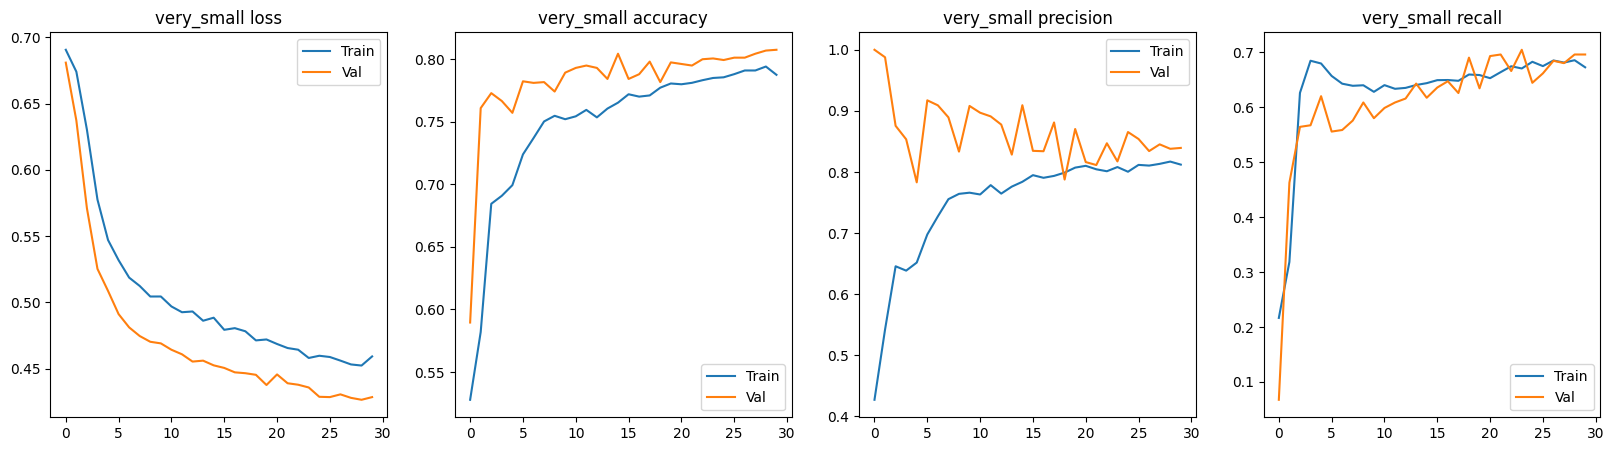


--- TESTING BINARY SMALL ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 87s 160ms/step - accuracy: 0.5945 - loss: 0.6725 - precision: 0.6379 - recall: 0.1801 - val_accuracy: 0.7093 - val_loss: 0.6220 - val_precision: 0.6354 - val_recall: 0.7966 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.7365 - loss: 0.5632 - precision: 0.7328 - recall: 0.6309 - val_accuracy: 0.6948 - val_loss: 0.5780 - val_precision: 0.6151 - val_recall: 0.8195 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 52s 163ms/step - accuracy: 0.7727 - loss: 0.5078 - precision: 0.7928 - recall: 0.6543 - val_accuracy: 0.7308 - val_loss: 0.5107 - val_precision: 0.6696 - val_recall: 0.7665 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 83s 157ms/step - accuracy: 0.7827 - loss: 0.4869 - precision: 0.8104 - recall: 0.6605 - val_accuracy: 0.7314 - val_loss: 0.5148 - val_precision: 0.6696 - val_recall: 0.7693 - learning_rate: 5.0000e-05
Epoch 

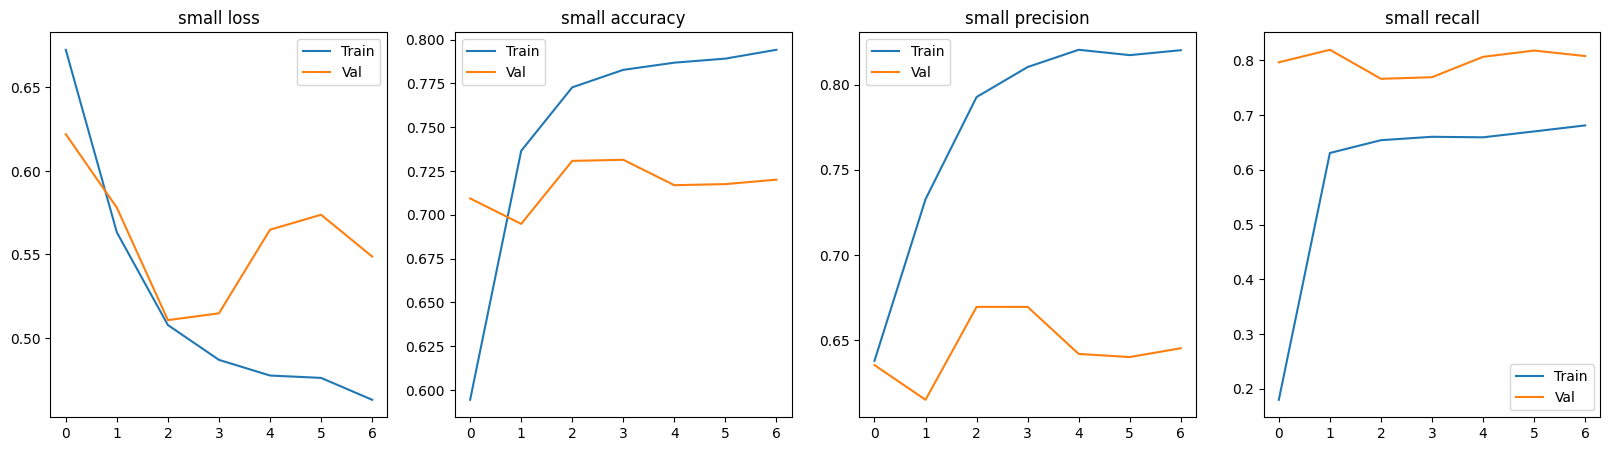


--- TESTING BINARY MEDIUM ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 102s 172ms/step - accuracy: 0.6154 - loss: 0.6666 - precision: 0.6763 - recall: 0.2406 - val_accuracy: 0.6658 - val_loss: 0.6058 - val_precision: 0.5809 - val_recall: 0.8639 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 50s 157ms/step - accuracy: 0.7859 - loss: 0.4812 - precision: 0.8290 - recall: 0.6464 - val_accuracy: 0.6803 - val_loss: 0.7188 - val_precision: 0.5941 - val_recall: 0.8639 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 42s 139ms/step - accuracy: 0.7954 - loss: 0.4623 - precision: 0.8491 - recall: 0.6505 - val_accuracy: 0.7465 - val_loss: 0.5306 - val_precision: 0.6733 - val_recall: 0.8238 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 96s 176ms/step - accuracy: 0.7995 - loss: 0.4491 - precision: 0.8443 - recall: 0.6672 - val_accuracy: 0.7774 - val_loss: 0.4806 - val_precision: 0.7175 - val_recall: 0.8152 - learning_rate: 5.0000e-05
Epoc

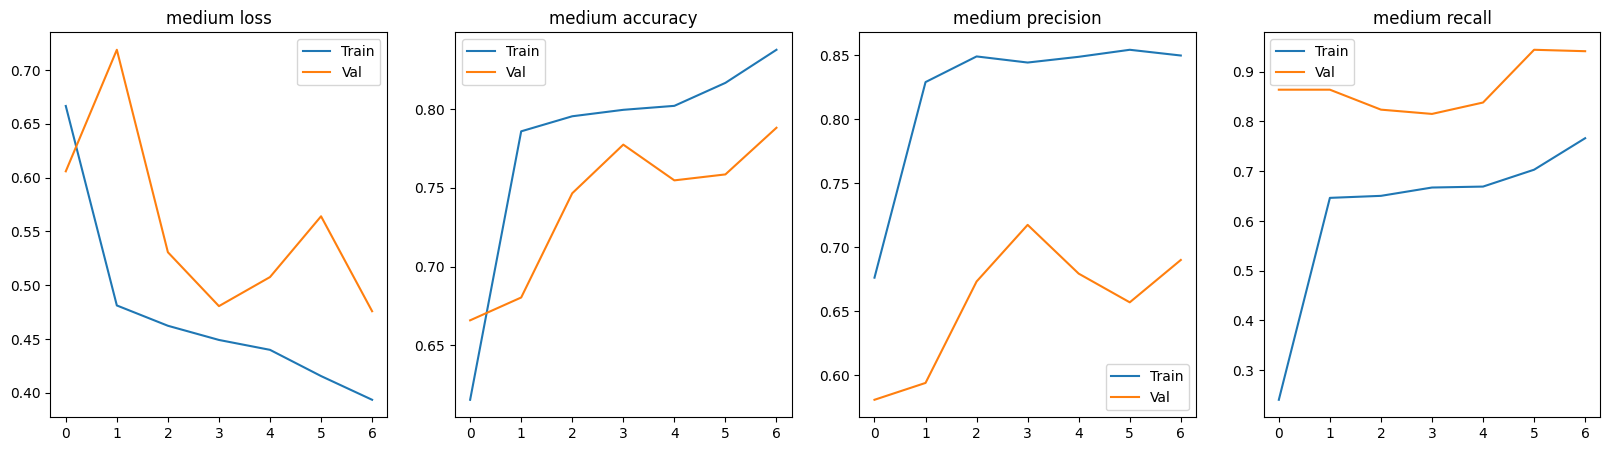


--- TESTING BINARY LARGE ---
Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 191s 501ms/step - accuracy: 0.7104 - loss: 0.5610 - precision: 0.8158 - recall: 0.4412 - val_accuracy: 0.7623 - val_loss: 0.5208 - val_precision: 0.7009 - val_recall: 0.8023 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 208s 513ms/step - accuracy: 0.8006 - loss: 0.4506 - precision: 0.8505 - recall: 0.6632 - val_accuracy: 0.8001 - val_loss: 0.4592 - val_precision: 0.7550 - val_recall: 0.8080 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 172s 569ms/step - accuracy: 0.8184 - loss: 0.4143 - precision: 0.8542 - recall: 0.7081 - val_accuracy: 0.8670 - val_loss: 0.3672 - val_precision: 0.8225 - val_recall: 0.8897 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 206s 570ms/step - accuracy: 0.8449 - loss: 0.3775 - precision: 0.8436 - recall: 0.7948 - val_accuracy: 0.8802 - val_loss: 0.3197 - val_precision: 0.8994 - val_recall: 0.8195 - learning_rate: 1.0000e-04
Ep

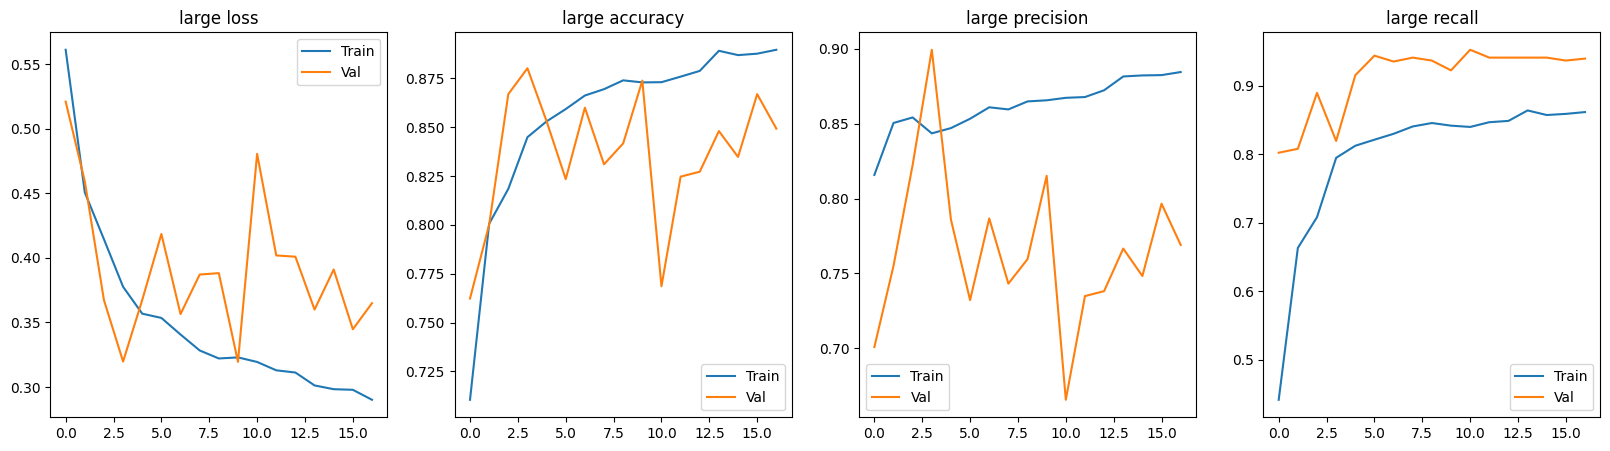

In [7]:
my_loss = 'binary_crossentropy' 
my_callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

all_results = {}
for model_size in ['very_small','small', 'medium', 'large']:
    all_results[model_size] = run_binary_experiment(model_size, my_loss, class_weights, my_callbacks)

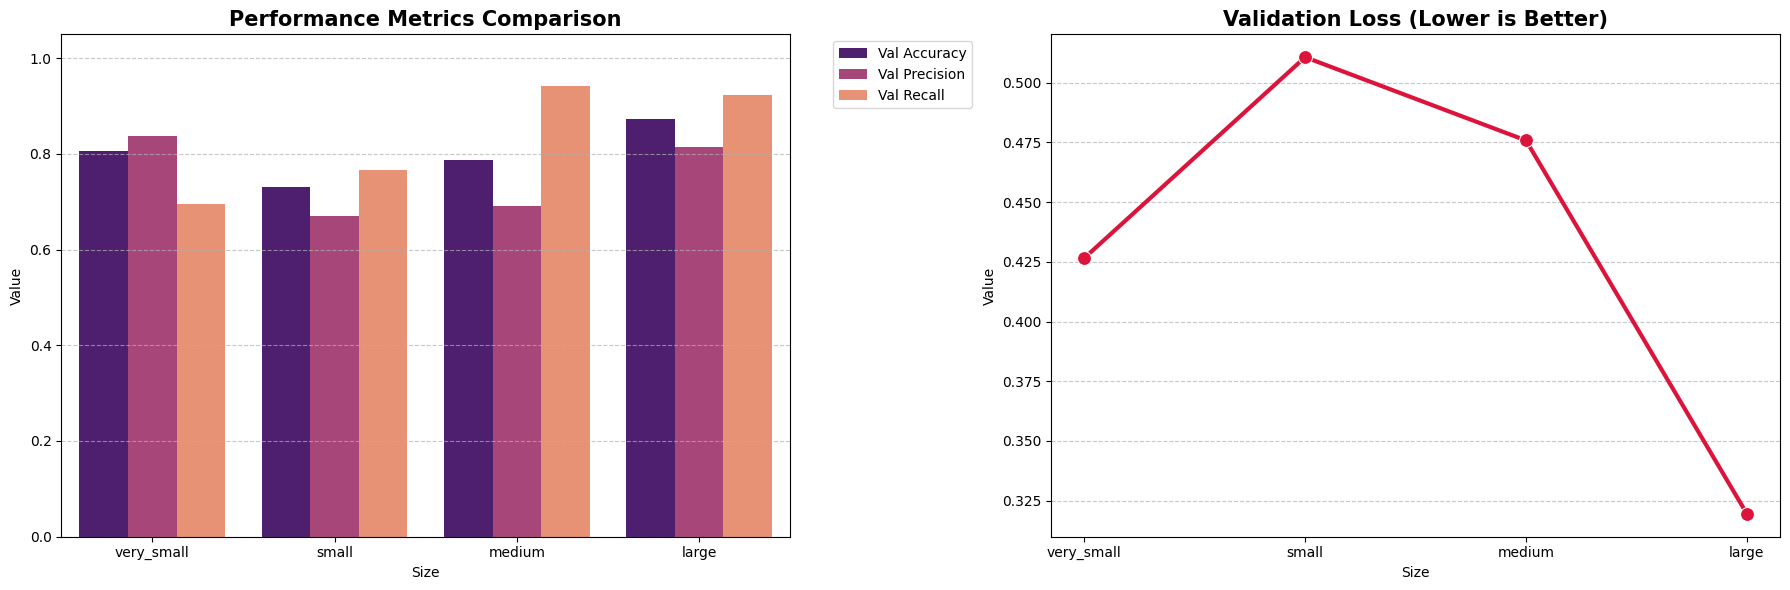

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(results_dict):
    data = []
    for size, result in results_dict.items():
        if isinstance(result, tuple):
            history_obj = result[1]
        else:
            history_obj = result
            
        h_dict = history_obj.history if hasattr(history_obj, 'history') else history_obj
        
        best_epoch = np.argmin(h_dict['val_loss'])
        
        row = {
            'Size': size,
            'Val Accuracy': h_dict['val_accuracy'][best_epoch],
            'Val Loss': h_dict['val_loss'][best_epoch],
        }
        
        if 'val_precision' in h_dict:
            row['Val Precision'] = h_dict['val_precision'][best_epoch]
        if 'val_recall' in h_dict:
            row['Val Recall'] = h_dict['val_recall'][best_epoch]
            
        data.append(row)

    df = pd.DataFrame(data)
    
    # ADD 'EfficientNetV2' TO THIS LIST:
    order = ['very_small', 'small', 'medium', 'large', 'EfficientNetV2']
    
    # Filter order to only include sizes actually present in the results
    actual_order = [s for s in order if s in df['Size'].values]
    
    # This line was turning 'EfficientNetV2' into NaN because it wasn't in actual_order
    df['Size'] = pd.Categorical(df['Size'], categories=actual_order, ordered=True)
    df = df.sort_values('Size')
    df_melted = df.melt(id_vars='Size', var_name='Metric', value_name='Value')
    df_metrics = df_melted[df_melted['Metric'] != 'Val Loss']
    df_loss = df_melted[df_melted['Metric'] == 'Val Loss']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    sns.barplot(data=df_metrics, x='Size', y='Value', hue='Metric', ax=ax1, palette='magma')
    ax1.set_title('Performance Metrics Comparison', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 1.05)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    sns.lineplot(data=df_loss, x='Size', y='Value', marker='o', ax=ax2, color='crimson', linewidth=3, markersize=10)
    ax2.set_title('Validation Loss (Lower is Better)', fontsize=15, fontweight='bold')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
plot_model_comparison(all_results)


--- TESTING EFFICIENTNETV2B0 (BINARY) ---

Epoch 1/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 66s 156ms/step - accuracy: 0.8490 - loss: 0.3376 - precision: 0.7978 - recall: 0.8796 - val_accuracy: 0.9508 - val_loss: 0.1485 - val_precision: 0.9068 - val_recall: 0.9900 - learning_rate: 1.0000e-04
Epoch 2/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 45s 150ms/step - accuracy: 0.9516 - loss: 0.1331 - precision: 0.9302 - recall: 0.9620 - val_accuracy: 0.9779 - val_loss: 0.0668 - val_precision: 0.9535 - val_recall: 0.9986 - learning_rate: 1.0000e-04
Epoch 3/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 45s 149ms/step - accuracy: 0.9747 - loss: 0.0770 - precision: 0.9636 - recall: 0.9795 - val_accuracy: 0.9874 - val_loss: 0.0315 - val_precision: 0.9748 - val_recall: 0.9971 - learning_rate: 1.0000e-04
Epoch 4/30
298/298 ━━━━━━━━━━━━━━━━━━━━ 45s 151ms/step - accuracy: 0.9787 - loss: 0.0653 - precision: 0.9702 - recall: 0.9816 - val_accuracy: 0.9918 - val_loss: 0.0243 - val_precision: 0.9900 - val_recall: 0.9914 - learning_rate: 1.0

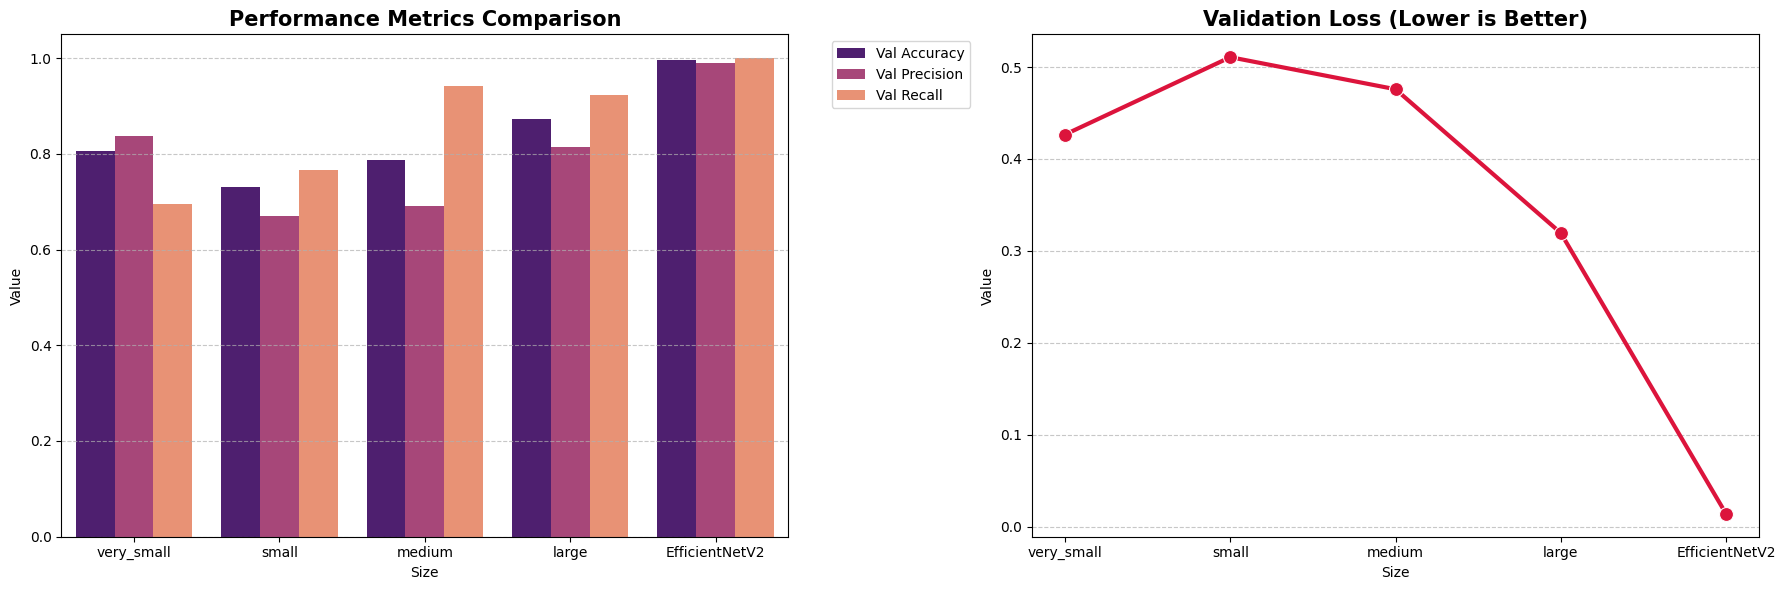

In [9]:
def build_effnet_binary_model(loss_fn=None):
    inputs = keras.layers.Input(shape=(96, 96, 3))
    
    # Scale [0, 1] back up to [0, 255] for EfficientNetV2's internal preprocessing
    x = keras.layers.Lambda(lambda tensor: tensor * 255.0)(inputs)

    # Load pre-trained EfficientNetV2B0 without the classification head
    base_model = keras.applications.EfficientNetV2B0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        input_shape=(96, 96, 3)
    )
    
    # We leave the base model trainable to fine-tune it on your specific fire data
    base_model.trainable = True

    # Rebuild the top layers
    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.models.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=loss_fn if loss_fn else 'binary_crossentropy',
        metrics=[
            'accuracy', 
            keras.metrics.Precision(name='precision'), 
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

# --- Run the EfficientNetV2 Experiment ---
print("\n--- TESTING EFFICIENTNETV2B0 (BINARY) ---")
effnet_bin_model = build_effnet_binary_model(my_loss)

history_effnet_bin = effnet_bin_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=my_callbacks,
    verbose=1
)

# Append to your existing results dictionary
all_results['EfficientNetV2'] = (effnet_bin_model, history_effnet_bin)

# Now, re-run your plot function to see the comparison!
plot_model_comparison(all_results)